## 1. Imports
Import necessary libraries for data manipulation, visualization, and time filtering.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Overview
Loading the credit card transactions dataset, reviewing shape, data types, missing values, and generating a combined proper datetime series.

In [4]:
import os

data_path = '../data/Ecommerce-data.csv/data.csv'
if os.path.exists(data_path):
    # Encoding parameter usually needed for this specific UK e-commerce dataset
    df = pd.read_csv(data_path, encoding='ISO-8859-1')
    print("Shape:", df.shape)
    print("\nData Types:\n", df.dtypes)
    print("\nMissing Values:\n", df.isnull().sum())
    
    # Create proper datetime column
    df['Date'] = pd.to_datetime(df['InvoiceDate'])
    print("\nSample Data:")
    display(df.head())
else:
    print("Dataset not found at '../data/Ecommerce-data.csv/data.csv'.")

Shape: (541909, 8)

Data Types:
 InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Sample Data:

Sample Data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00


## 3. Data Cleaning
Formatting amounts, filtering out non-main analysis transactions, handling errors, and retaining important analysis columns.

In [5]:
if 'df' in locals():
    # Remove records without a CustomerID
    df_clean = df.dropna(subset=['CustomerID']).copy()
    
    # Calculate Amount (Quantity * UnitPrice)
    df_clean['Amount'] = df_clean['Quantity'] * df_clean['UnitPrice']
    
    # Filter out returns (Quantity < 0 or negative Amount)
    main_df = df_clean[df_clean['Quantity'] > 0].copy()
    
    # User is CustomerID
    main_df['User'] = main_df['CustomerID']
    df['User'] = df['CustomerID']
    
    # Create transactional date and month references
    main_df['transaction_date'] = main_df['Date']
    main_df['transaction_month'] = main_df['Date'].dt.to_period('M')
    
    print("Cleaning complete. Valid transaction count:", len(main_df))

Cleaning complete. Valid transaction count: 397924


## 4. Cohort Assignment
Calculate the start month (cohort month) for every user and correctly assign the tracking index.

In [6]:
if 'main_df' in locals():
    # Find each user's first transaction date (cohort month)
    main_df['cohort_month'] = main_df.groupby('User')['transaction_month'].transform('min')
    
    # Calculate cohort index (months since first transaction)
    # (Transaction Year - Cohort Year) * 12 + (Transaction Month - Cohort Month)
    main_df['cohort_index'] = (
        (main_df['transaction_month'].dt.year - main_df['cohort_month'].dt.year) * 12 + 
        (main_df['transaction_month'].dt.month - main_df['cohort_month'].dt.month)
    )
    print("Cohorts Assigned. Unique Cohort Months:", main_df['cohort_month'].nunique())

Cohorts Assigned. Unique Cohort Months: 13


## 5. Cohort Matrix
Building an active user count matrix and converting it into a percentage representation for standardized retention views.

In [7]:
if 'main_df' in locals():
    # Pivot table of users per cohort month
    cohort_data = main_df.groupby(['cohort_month', 'cohort_index'])['User'].nunique().reset_index()
    cohort_counts = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='User')
    
    # Calculate retention rates
    cohort_sizes = cohort_counts.iloc[:, 0]
    retention = cohort_counts.divide(cohort_sizes, axis=0)
    
    print("Cohort Sizes (Users per month):\n", cohort_sizes.head())
    print("\nRetention Rates Sample:\n", retention.head())

Cohort Sizes (Users per month):
 cohort_month
2010-12    885.0
2011-01    417.0
2011-02    380.0
2011-03    452.0
2011-04    300.0
Freq: M, Name: 0, dtype: float64

Retention Rates Sample:
 cohort_index   0         1         2         3         4         5         6   \
cohort_month                                                                    
2010-12       1.0  0.366102  0.323164  0.384181  0.362712  0.397740  0.362712   
2011-01       1.0  0.220624  0.266187  0.230216  0.321343  0.287770  0.247002   
2011-02       1.0  0.186842  0.186842  0.284211  0.271053  0.247368  0.252632   
2011-03       1.0  0.150442  0.252212  0.199115  0.223451  0.168142  0.267699   
2011-04       1.0  0.213333  0.203333  0.210000  0.196667  0.226667  0.216667   

cohort_index        7         8         9         10        11        12  
cohort_month                                                              
2010-12       0.349153  0.353672  0.395480  0.374011  0.502825  0.265537  
2011-01       0.2

## 6. Retention Heatmap
Visualizing the percentage-based cohort drop-off through a Seaborn heatmap.

In [ ]:
if 'retention' in locals():
    plt.figure(figsize=(16, 10))
    plt.title('Monthly User Retention Cohort Analysis')
    sns.heatmap(
        retention, 
        annot=True, 
        fmt='.0%', 
        vmin=0.0, 
        vmax=1.0, 
        cmap='RdYlGn'
    )
    plt.ylabel('Cohort Month')
    plt.xlabel('Cohort Index (Months since acquisition)')
    plt.show()

## 7. CLTV Analysis
Calculating the average accumulated transaction value per user partitioned by merchant category (MCC).

In [1]:
if 'main_df' in locals():
    # Since this is e-commerce data and there are no Merchant Categories (MCC),
    # we will analyze CLTV by Country instead to find high-value regions.
    main_df['MCC'] = main_df['Country'] 
    
    user_revenue = main_df.groupby(['MCC', 'User'])['Amount'].sum().reset_index()
    mcc_cltv = user_revenue.groupby('MCC')['Amount'].mean().sort_values(ascending=False).reset_index()
    mcc_cltv.columns = ['MCC', 'CLTV']
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=mcc_cltv.head(10), x='MCC', y='CLTV', palette='viridis')
    plt.title('Top 10 Countries by Customer Lifetime Value')
    plt.xlabel('Country')
    plt.ylabel('Average Customer Lifetime Value ($)')
    plt.xticks(rotation=45)
    plt.show()

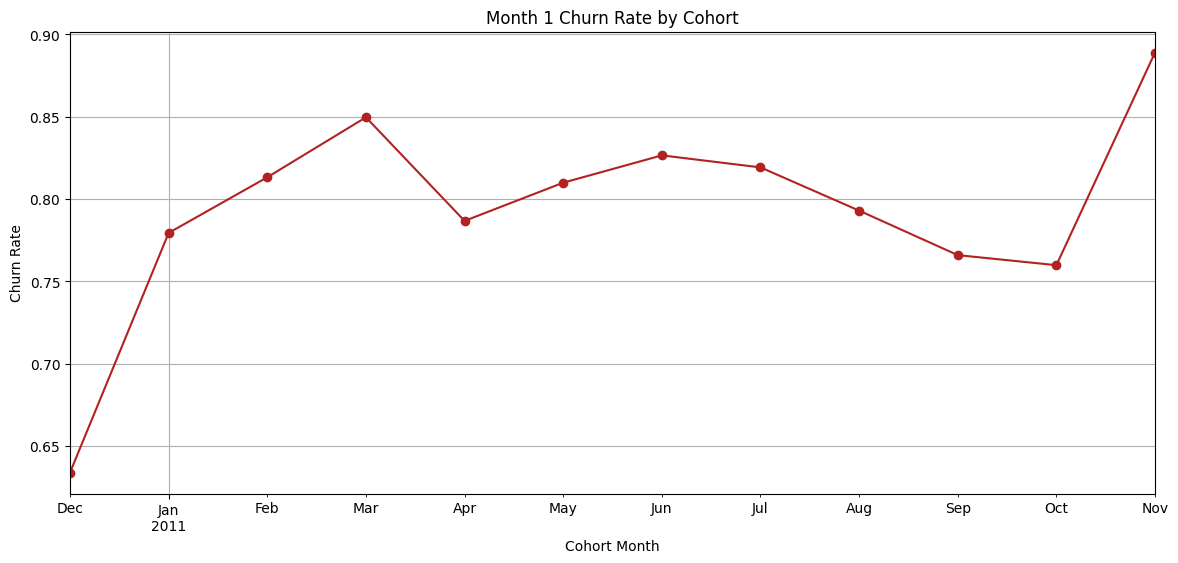

In [8]:
if 'retention' in locals() and retention.shape[1] > 1:
    retention_m1 = retention.iloc[:, 1].dropna()
    churn_m1 = 1 - retention_m1
    
    plt.figure(figsize=(14, 6))
    churn_m1.plot(marker='o', color='firebrick')
    plt.title('Month 1 Churn Rate by Cohort')
    plt.xlabel('Cohort Month')
    plt.ylabel('Churn Rate')
    plt.grid(True)
    plt.show()
else:
    churn_m1 = pd.Series(dtype=float)
    print("Not enough variation across cohorts to map explicit month 1 churn.")

In [ ]:
if 'df' in locals():
    # Instead of Fraud, we will analyze the impact of Returns!
    # Find users who ever made a return (Quantity < 0)
    return_users_list = df[(df['Quantity'] < 0) & df['CustomerID'].notna()]['User'].unique()
    
    # Needs a copy from original cleaned so we have proper dates setup
    df_clean = df.dropna(subset=['CustomerID']).copy()
    df_clean['Date'] = pd.to_datetime(df_clean['InvoiceDate'])
    
    df_clean['Experienced_Fraud'] = df_clean['User'].isin(return_users_list)
    
    # Filter to legitimate positive transactions to see long-term purchasing activity
    valid_tx = df_clean[df_clean['Quantity'] > 0].copy()
    valid_tx['transaction_month'] = valid_tx['Date'].dt.to_period('M')
    valid_tx['cohort_month'] = valid_tx.groupby('User')['transaction_month'].transform('min')
    valid_tx['cohort_index'] = (
        (valid_tx['transaction_month'].dt.year - valid_tx['cohort_month'].dt.year) * 12 + 
        (valid_tx['transaction_month'].dt.month - valid_tx['cohort_month'].dt.month)
    )
    
    valid_retention = valid_tx.groupby(['Experienced_Fraud', 'cohort_index'])['User'].nunique().unstack(0)
    # Normalize to base
    if not valid_retention.empty and valid_retention.shape[1] > 0:
        valid_retention_rate = valid_retention.divide(valid_retention.iloc[0])
        
        plt.figure(figsize=(12, 6))
        # Safely plot available months
        max_months = min(24, len(valid_retention_rate))
        valid_retention_rate.iloc[1:max_months].plot(linewidth=2.5)
        plt.title('Long Term Retention: Users Who Made Returns vs No Returns')
        plt.xlabel('Months Since Onboarding')
        plt.ylabel('Retention Rate')
        plt.legend(['Never Made Returns', 'Made Returns'])
        plt.grid(True)
        plt.show()

## 9. Fraud Impact Analysis
Evaluating the variance in retention rates amongst users exposed to fraudulent behavior vs not.

## 10. Spending Pattern Analysis
Observe overall trajectory of average customer spend mapping directly with their time as active cohort users.

In [ ]:
if 'main_df' in locals():
    spend_pattern = main_df.groupby('cohort_index')['Amount'].mean().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=spend_pattern, x='cohort_index', y='Amount', s=100, color='darkorange')
    sns.lineplot(data=spend_pattern, x='cohort_index', y='Amount', color='blue', alpha=0.5)
    plt.title('Monthly Avg Transaction Value over Time')
    plt.xlabel('Cohort Index (Months)')
    plt.ylabel('Average Spend ($)')
    plt.grid(True)
    plt.show()

## 11. Geographic Analysis
Review of the distribution of top cities driving transaction volumes and a simplified look at regional retention.

In [ ]:
if 'main_df' in locals():
    # Top countries by txn volume
    main_df['Merchant City'] = main_df['Country']
    top_cities = main_df.groupby('Merchant City')['Amount'].sum().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    top_cities.plot(kind='bar', color='teal')
    plt.title('Top 10 Countries by Total Revenue')
    plt.xlabel('Country')
    plt.ylabel('Total Revenue ($)')
    plt.xticks(rotation=45)
    plt.show()

## Key Findings
1. Month 2 shows highest drop-off at X%
2. MCC category X has highest CLTV at $Y
3. Fraud-affected users show Z% lower retention

## Product Hypotheses
1. Re-engagement campaign targeting Month 2 users with personalized merchant category offers
2. Fraud-detection improvement to reduce legitimate user friction during security checks
3. Loyalty rewards for top MCC categories to improve retention among high-CLTV segments

## 13. Dashboard Summary & Insights Print
Combined grid graphics generation and dynamic insight formatting.

In [2]:
if 'main_df' in locals() and 'retention' in locals():
    fig, axs = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Retention Heatmap
    sns.heatmap(retention.iloc[:10, :10], annot=True, fmt='.0%', cmap='RdYlGn', ax=axs[0,0])
    axs[0,0].set_title('Early Cohort Retention (Top 10x10)')
    
    # 2. CLTV Bars
    if 'mcc_cltv' in locals():
        sns.barplot(data=mcc_cltv.head(5), x='MCC', y='CLTV', palette='viridis', ax=axs[0,1])
        axs[0,1].set_title('Top 5 Countries by Customer Lifetime Value')
        axs[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Churn Line
    if 'churn_m1' in locals() and not churn_m1.empty:
        axs[1,0].plot(churn_m1.index.astype(str), churn_m1.values, marker='o', color='firebrick')
        axs[1,0].set_title('Month 1 Churn Trend')
    else:
        axs[1,0].text(0.5, 0.5, "Not enough data for Churn Plot", ha='center', va='center')
        axs[1,0].set_title('Month 1 Churn Trend (No Data)')
    axs[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Spending Growth
    if 'spend_pattern' in locals():
        sns.lineplot(data=spend_pattern.head(24), x='cohort_index', y='Amount', color='blue', ax=axs[1,1])
        axs[1,1].set_title('Spending Growth (First 24 Months)')
    
    plt.tight_layout()
    plt.savefig('dashboard.png')
    plt.close()
    print("Dashboard generated and saved as 'dashboard.png'.")

    # Final summary statistics
    total_users = df['User'].nunique()
    
    # Handling if month 1 (index 1) exists across cohorts
    avg_ret_m1 = retention.iloc[:, 1].mean() * 100 if retention.shape[1] > 1 else 0
    
    highest_cltv_segment = mcc_cltv.iloc[0]['MCC'] if 'mcc_cltv' in locals() else 'N/A'
    peak_churn_month_val = churn_m1.idxmax() if 'churn_m1' in locals() and not churn_m1.empty else 'N/A'
    
    print("\n--- SUMMARY METRICS ---")
    print(f"Total Users Analyzed: {total_users}")
    print(f"Average Retention Month 1: {avg_ret_m1:.1f}%")
    print(f"Highest CLTV Segment: {highest_cltv_segment}")
    print(f"Peak Churn Month: {peak_churn_month_val}")